In [1]:
import numpy as np
from scipy.sparse import diags
from matplotlib import pyplot as plt
plt.style.use("default")

In [2]:
hbar = c = 1  # as god intended
mass = 50   # example
omega = 1  # example

n = 128  # number of elements
x, dx = np.linspace(-1, 1, n, retstep=True)  # real-space
d2_by_dx2 = diags([1., -2., 1.], [-1, 0, 1], shape=(n, n)).toarray() / (dx ** 2)  # 2nd derivative (approx)

### Simple Harmonic Oscillator
$$
\begin{align}
\hat{H} &= \hat{T} + \hat{V}
\\
\hat{V} &= \frac{1}{2} m \omega^{2} x^{2}
%  - q E x
\\
\hat{T} &= -\frac{1}{2m} \frac{\partial^{2}}{\partial x^{2}}
\end{align}
$$

$$
\begin{align}
\hat{H} |\psi\rangle = E |\psi\rangle
\\
\hat{H} = -\frac{1}{2m} \frac{\partial^{2}}{\partial x^{2}} + \hat{V}(r)
\end{align}
$$

In [3]:
def harmonic_oscillator_potential(x,
                                  omega=omega,
                                  m=mass):
    V_vector = 0.5 * m * omega ** 2 * x ** 2  # calculate the potential
    V_matrix = diags(V_vector).toarray()  # slap that bitch on the diagonal
    return V_matrix

# def normalize(psi):
#     psi_dagger = psi.transpose().conjugate()
#     normalized_psi = psi / (np.abs(psi_dagger @ psi) ** 2)
#     return normalized_psi

In [4]:
T = - (1 / (2 * mass)) * d2_by_dx2
V = harmonic_oscillator_potential(x)
H = T + V  # H psi = E psi  <- omg an eigenvalue problem!

eigenvalues, eigenvectors = np.linalg.eigh(H)

/var/folders/58/xrmpvhh11mj0pb2kfrznw9qh0000gn/T/ipykernel_45555/3953114748.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


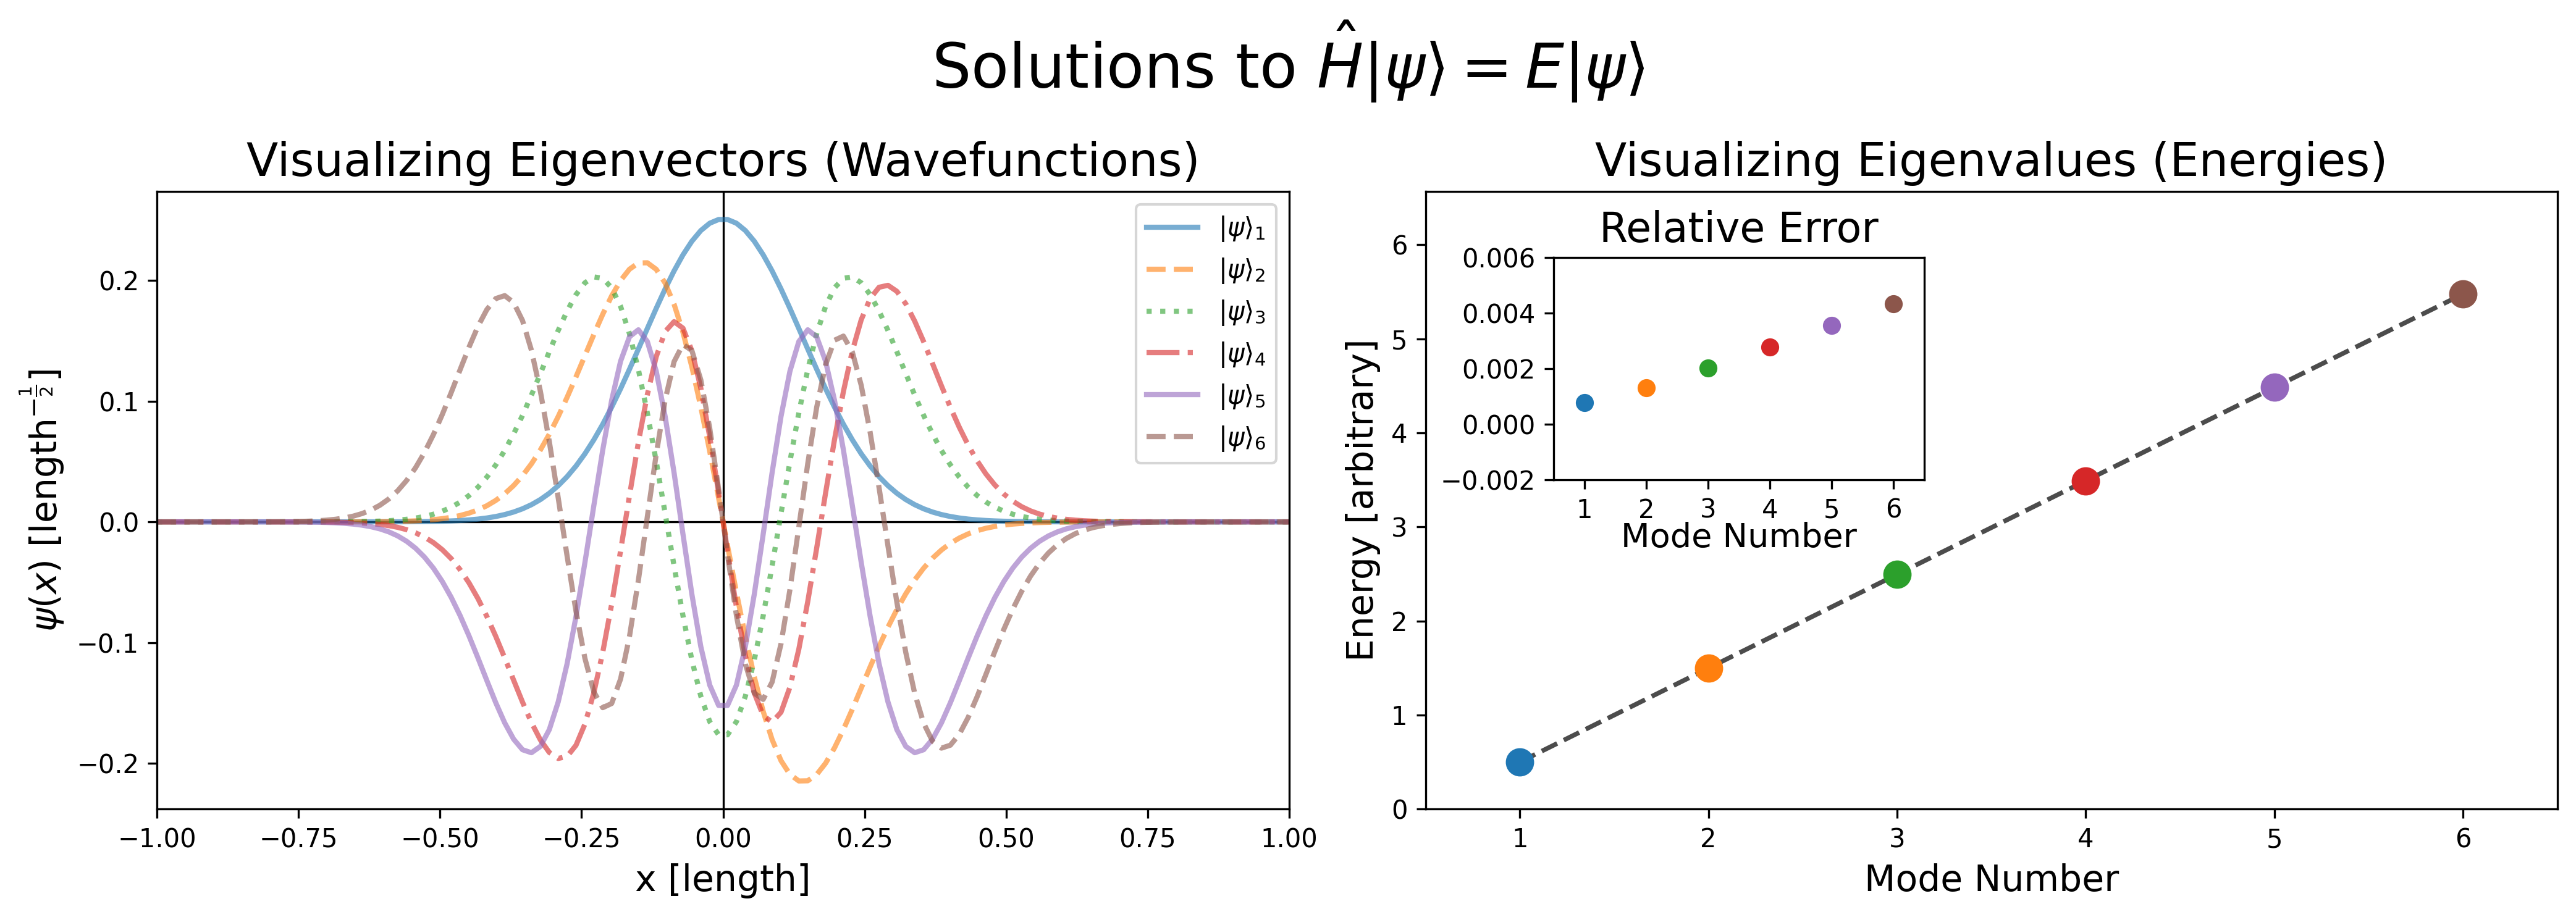

In [13]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

modes_to_show = 6
linestyles = ["-", "--", ":", "-."]
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(7 * 2, 5))
fig.suptitle(r"Solutions to $\hat{H} |\psi\rangle = E |\psi\rangle$", fontsize=24)

# eigenvectors
ax[0].set_title("Visualizing Eigenvectors (Wavefunctions)", fontsize=18)
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].axvline(0, color="black", linewidth=0.8)
for mode in np.arange(modes_to_show):
    ax[0].plot(x, -eigenvectors[:, mode], linewidth=2, alpha=0.6, 
               linestyle=linestyles[mode % len(linestyles)], label=r"$|\psi\rangle$" + rf"$_{mode + 1}$")
ax[0].set_xlabel("x [length]", fontsize=14)
ax[0].set_xlim(x[0], x[-1])
ax[0].set_ylabel(r"$\psi(x)$ [length$^{-\frac{1}{2}}$]", fontsize=14)
ax[0].legend()

# eigenvalues
inset_E_error = inset_axes(ax[1],
                           width=2.0,
                           height=1.2,
                           loc="upper center",
                           bbox_to_anchor=(2830, 1125),  # jesus christ
                           borderpad=1)

ax[1].set_title("Visualizing Eigenvalues (Energies)", fontsize=18)
ax[1].plot(np.arange(1, modes_to_show + 1), eigenvalues[:modes_to_show], 
           color="black", linewidth=1.8, linestyle="--", alpha=0.7)
for mode in np.arange(modes_to_show):
    ax[1].plot(mode + 1, eigenvalues[mode], marker="o", markersize=10)
    E_exact = omega / 2 + (mode)
    inset_E_error.plot(mode + 1, (E_exact - eigenvalues[mode]) / E_exact, marker="o")
ax[1].set_xlabel("Mode Number", fontsize=14)
ax[1].set_xlim(0.5, modes_to_show + 0.5)
ax[1].set_ylabel("Energy [arbitrary]", fontsize=14)
ax[1].set_ylim(0, eigenvalues[modes_to_show] + 0.1)

inset_E_error.set_title("Relative Error", fontsize=16)
inset_E_error.set_xlabel("Mode Number", fontsize=13, labelpad=-0.8)
inset_E_error.set_xlim(0.5, modes_to_show + 0.5)
inset_E_error.set_xticks([1, 2, 3, 4, 5, 6])
inset_E_error.set_ylim(-0.002, 0.006)


plt.tight_layout()
plt.savefig("classical_eigensolver.png")
plt.show()

In [6]:
print(r"Energies (n + omega / 2) = ")
print(eigenvalues[:modes_to_show])

Energies (n + omega / 2) = 
[0.4996122  1.49805978 2.49495192 3.49028495 4.48405519 5.4762589 ]


In [7]:
test_psi = np.copy(eigenvectors[:, np.random.randint(n)])
print(f"1 ?= {test_psi.transpose().conjugate() @ test_psi}")

1 ?= 1.0


In [8]:
print(f"H = psi @ e @ psi^dagger  max error = {np.max(H - (eigenvectors @ diags(eigenvalues) @ eigenvectors.transpose().conjugate())):.4}")

H = psi @ e @ psi^dagger  max error = 1.705e-13
